In [1]:
# First, we import everything we need. Lightweaver is typically imported as
# `lw`, but things like the library of model atoms and Fal atmospheres need to
# be imported separately.
import lightweaver as lw
from lightweaver.fal import Falc82
from lightweaver.rh_atoms import H_6_atom, H_6_CRD_atom, H_3_atom, C_atom, O_atom, OI_ord_atom, \
                                 Si_atom, Al_atom, CaII_atom, Fe_atom, FeI_atom, He_9_atom, \
                                 He_atom, He_large_atom, MgII_atom, N_atom, Na_atom, S_atom

import numpy as np
from scipy.interpolate import interpn, interp1d
import os, time
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from joblib import Parallel, delayed

In [2]:
# Load the saved predictions and targets from the GNN inference step.
checkpoint_path = '/dat/andreuva/gpu/graphnet/graphnet_nlte/checkpoints/multistride_cpudtst_4x4_s4_m8_b8_r6_d025_press/2026.03.01-02:16:27_best.pth'

# Load the entire checkpoint
checkpoint = torch.load(checkpoint_path, weights_only=False)

# Extract the configuration object used for training
config = checkpoint['config']
datadir = config['data']['datadir']
nx, ny, nz = config['data']['nx'], config['data']['ny'], config['data']['nz_orig']
nlev = config['data']['nlev']
nz_linear = config['dataset']['nz_linear']
nz_log = config['dataset']['nz_log']
new_nz = nz_linear + nz_log
logspace_fraction = config['dataset']['logspace_fraction']
log_offset = config['normalization']['log_offset']
normalization_type = config['normalization'].get('type', 'log')

print(f"Successfully loaded configuration from checkpoint {checkpoint_path}.")

Successfully loaded configuration from checkpoint /dat/andreuva/gpu/graphnet/graphnet_nlte/checkpoints/multistride_cpudtst_4x4_s4_m8_b8_r6_d025_press/2026.03.01-02:16:27_best.pth.


In [3]:
# Load the saved predictions and targets from the GNN inference step.
stride = 2
dataset_type = 'test'
predictions_denorm = np.load(f'{config['training']['savedir']}predictions_patch_stride_{stride}_{dataset_type}.npy')
targets_denorm = np.load(f'{config['training']['savedir']}targets_patch_stride_{stride}_{dataset_type}.npy')

_, ny_patch, nx_patch, _ = predictions_denorm.shape

print(f"Predictions shape: {predictions_denorm.shape}")
print(f"Targets shape: {targets_denorm.shape}")

Predictions shape: (50, 141, 141, 6)
Targets shape: (50, 141, 141, 6)


In [4]:
z, y, x = (np.arange(d) for d in (nz, ny, nx))
new_z_log = np.concatenate([
    np.linspace(0, nz * logspace_fraction, nz_linear, endpoint=False),
    np.logspace(np.log10(nz * logspace_fraction), np.log10(nz - 1), nz_log)
])
new_z = np.clip(new_z_log, 0, nz - 1)
new_y, new_x = (np.linspace(0, d - 1, new_d) for d, new_d in zip((ny, nx), (ny, nx)))
new_zv, new_yv, new_xv = np.meshgrid(new_z, new_y, new_x, indexing='ij', sparse=True)

In [5]:
# ---- memory–mapped arrays ----
pops_orig = np.memmap(f'{datadir}/AR_385_CaII_5L_pops.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, nlev))
b_xyz_orig = np.memmap(f'{datadir}/AR_385_B.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 3))
temp_orig = np.memmap(f'{datadir}/AR_385_temp.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
vel_orig = np.memmap(f'{datadir}/AR_385_veloc.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 3))
n_e_orig = np.memmap(f'{datadir}/AR_385_ne.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
# n_h_orig = np.memmap(f'{datadir}/AR_385_nh.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
# n_p_orig = np.memmap(f'{datadir}/AR_385_np.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
rho_orig = np.memmap(f'{datadir}/AR_385_mass.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))
press_orig = np.memmap(f'{datadir}/AR_385_press.dat', dtype='<f4', mode='r', shape=(nz, ny, nx, 1))

# load geometry grid
geometry_file = config["data"]["grid_file"]
geometry_grid = np.load(geometry_file)["z"]
zz_grid = np.interp(new_z, z, geometry_grid)

In [6]:
# Define shifted points for the populations (Shifted by 1.5)
# We clip to ensure we don't go out of bounds of the original z grid (0 to nz-1)
z_shift = 0
# new_zv_shifted = np.clip(new_zv - z_shift, 0, nz - 1)
# new_points_pops = (new_zv_shifted, new_yv, new_xv)
# pops = interpn((z, y, x), pops_orig, new_points_pops)

In [7]:
print(f"Interpolating data to the new grid ({new_nz}, {ny}, {nx})...")

new_points = (new_zv, new_yv, new_xv)
pops = interpn((z, y, x), pops_orig, new_points)
temp = interpn((z, y, x), temp_orig, new_points)
b_xyz = interpn((z, y, x), b_xyz_orig, new_points)
vel = interpn((z, y, x), vel_orig, new_points)
n_e = interpn((z, y, x), n_e_orig, new_points)
# n_h = interpn((z, y, x), n_h_orig, new_points)
# n_p = interpn((z, y, x), n_p_orig, new_points)
rho = interpn((z, y, x), rho_orig, new_points)
press = interpn((z, y, x), press_orig, new_points)
print("Interpolation complete.")
print(f"Original shape: ({nz}, {ny}, {nx})")
print(f"New shape: {pops.shape}")

Interpolating data to the new grid (50, 504, 504)...
Interpolation complete.
Original shape: (425, 504, 504)
New shape: (50, 504, 504, 6)


In [8]:
atmosRef = Falc82()

Loaded geometry grid from ../en024048_hion/grid_bifrost.npz with shape (50,).


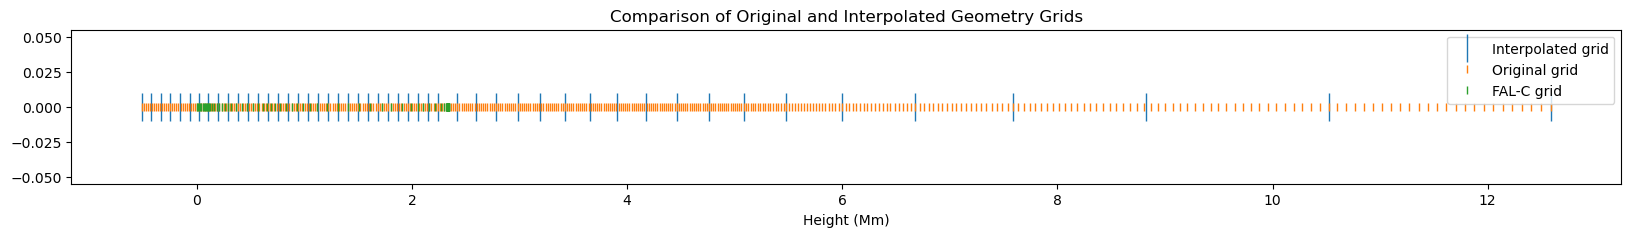

In [9]:
print(f"Loaded geometry grid from {geometry_file} with shape {zz_grid.shape}.")
plt.figure(figsize=(20, 2))
plt.plot(zz_grid, zz_grid * 0, '|', markersize=20, label='Interpolated grid')
plt.plot(geometry_grid, geometry_grid * 0, '|', label='Original grid')
plt.plot(atmosRef.z/1e6, atmosRef.z * 0, '|', label='FAL-C grid')
plt.xlabel('Height (Mm)')
plt.legend()
plt.title('Comparison of Original and Interpolated Geometry Grids')

plt.show()
# plt.close()

In [10]:
# convert zz_grid to meters
# zz_grid_m = (zz_grid-1.5) * 1e6  # Mm to m
zz_grid_m = (zz_grid) * 1e6  # Mm to m

In [11]:
# We wrap the inner loop logic in a function
def process_single_row(row_idx, ny_patch, 
                      # nx_patch, nz, 
                       temp,
                       b_xyz,
                       vel, 
                       n_e,
                      # n_h, 
                      # n_p,
                      rho,
                      press,
                      # pops, 
                       predictions_denorm, targets_denorm,
                      #  new_z,
                       zz_grid_m, wave):
    
    # Pre-allocate arrays for this specific row to store results
    # Shape: (ny_patch, nwave)
    row_lte = np.zeros((ny_patch, len(wave)))
    row_1dnlte = np.zeros((ny_patch, len(wave)))
    row_target = np.zeros((ny_patch, len(wave)))
    row_pred = np.zeros((ny_patch, len(wave)))
    
    # Iterate over columns in this row
    for col_pix in range(ny_patch):
        
        # --- 1. Extract Data (Slicing logic from original code) ---
        # Note: We slice at [row_idx] fixed, iterating [col_pix]
        temp_atm = np.ascontiguousarray(temp[-1:1:-1, col_pix, row_idx, 0])
        b_xyz_atm = np.ascontiguousarray(b_xyz[-1:1:-1, col_pix, row_idx, 2])
        vel_atm = np.ascontiguousarray(vel[-1:1:-1, col_pix, row_idx, 2])/1e2
        n_e_atm = np.ascontiguousarray(n_e[-1:1:-1, col_pix, row_idx, 0])*1e6
        # n_h_atm = np.ascontiguousarray(n_h[-1:1:-1, col_pix, row_idx, 0])*1e6
        # n_p_atm = np.ascontiguousarray(n_p[-1:1:-1, col_pix, row_idx, 0])*1e6
        # rho_atm = np.ascontiguousarray(rho[-1:1:-1, col_pix, row_idx, 0])
        press_atm = np.ascontiguousarray(press[-1:1:-1, col_pix, row_idx, 0])
        pops_atm = np.ascontiguousarray(pops[-1:1:-1, col_pix, row_idx, :])*1e6
        
        prediction_atm = np.ascontiguousarray(predictions_denorm[-1:1:-1, col_pix, row_idx, :])*1e6
        target_atm = np.ascontiguousarray(targets_denorm[-1:1:-1, col_pix, row_idx, :])*1e6

        # --- 3. Lightweaver Setup (Pre/LTE) ---
        atmos_pre = lw.Atmosphere.make_1d(scale=lw.ScaleType.Geometric, 
                                          depthScale=np.ascontiguousarray(zz_grid_m[-1:1:-1]),
                                          convertScales=False,
                                          temperature=temp_atm,
                                          # ne=n_e_atm,
                                          # nHTot=n_h_atm,
                                          Pgas=press_atm,
                                          vturb=1e3*np.ones_like(temp_atm),
                                          vlos=vel_atm)
        atmos_pre.quadrature(5)
        
        # Re-instantiate atoms inside the worker to avoid pickling issues with C++ objects
        aSet_pre = lw.RadiativeSet([H_6_atom(), C_atom(), OI_ord_atom(), Si_atom(), Al_atom(), CaII_atom(),
                                    Fe_atom(), He_9_atom(), MgII_atom(), N_atom(), Na_atom(), S_atom()])
        aSet_pre.set_active('H', 'Ca')
        spect_pre = aSet_pre.compute_wavelength_grid()

        eqPops_pre = aSet_pre.compute_eq_pops(atmos_pre)
        ctx_pre = lw.Context(atmos_pre, spect_pre, eqPops_pre, Nthreads=1, conserveCharge=False)

        # Compute LTE intensity
        row_lte[col_pix, :] = ctx_pre.compute_rays(wave, [atmos_pre.muz[-1]], stokes=False)

        # CONVERGE 1D NLTE ATMOSPHERE
        try:
            aSet_pre.set_active('H', 'Ca')
            eqPops_pre = aSet_pre.iterate_lte_ne_eq_pops(atmos_pre, quiet=True, direct=True)
            ctx_pre = lw.Context(atmos_pre, spect_pre, eqPops_pre, conserveCharge=True, Nthreads=2)
            lw.iterate_ctx_se(ctx_pre, quiet=True)
            eqPops_pre.update_lte_atoms_Hmin_pops(atmos_pre)
            row_1dnlte[col_pix, :] = ctx_pre.compute_rays(wave, [atmos_pre.muz[-1]], stokes=False)
        except Exception as e:
            print(f'Error catched: {e}')
            print(f'Convergence of pix ({row_idx},{col_pix}) failed, intensity zeroed.')

        # --- 4. NLTE Computations ---
        atmos = lw.Atmosphere.make_1d(scale=lw.ScaleType.Geometric, 
                                      depthScale=np.ascontiguousarray(zz_grid_m[-1:1:-1]),
                                      convertScales=False,
                                      temperature=temp_atm, 
                                      # ne=n_e_atm,
                                      # nHTot=n_h_atm,
                                      Pgas=press_atm,
                                      vturb=1e3*np.ones_like(temp_atm),
                                      vlos=vel_atm)
        atmos.quadrature(5)
        aSet = lw.RadiativeSet([H_6_atom(), C_atom(), OI_ord_atom(), Si_atom(), Al_atom(), CaII_atom(),
                                Fe_atom(), He_9_atom(), MgII_atom(), N_atom(), Na_atom(), S_atom()])
        aSet.set_active('H', 'Ca')
        spect = aSet.compute_wavelength_grid()
        eqPops = aSet.compute_eq_pops(atmos)

        # Target Populations
        eqPops.atomicPops['Ca'].n = np.ascontiguousarray(np.moveaxis(prediction_atm, 1, 0))
        ctx = lw.Context(atmos, spect, eqPops, Nthreads=1, conserveCharge=False)
        row_target[col_pix, :] = ctx.compute_rays(wave, [atmos.muz[-1]], stokes=False)

        # Predicted Populations
        eqPops.atomicPops['Ca'].n = np.ascontiguousarray(np.moveaxis(target_atm, 1, 0))
        ctx = lw.Context(atmos, spect, eqPops, Nthreads=1, conserveCharge=False)
        row_pred[col_pix, :] = ctx.compute_rays(wave, [atmos.muz[-1]], stokes=False)

    return row_idx, row_lte, row_1dnlte, row_target, row_pred

In [12]:
# --- Setup Constants ---
nwave = 1001
wave = np.linspace(853.9444, 854.9444, nwave)

# --- Execute Parallel Loop ---
print(f'Starting parallel synthesis on grid: {nx_patch}x{ny_patch}...')
start_time = time.time()

# n_jobs=-1 uses all available cores. 
# verbose=5 provides progress updates.
results = Parallel(n_jobs=100, verbose=5)(
    delayed(process_single_row)(
        row, ny_patch,
        # nx_patch, nz, 
        temp,
        b_xyz,
        vel, 
        n_e,
        # n_h,
        # n_p,
        rho,
        press,
        # pops, 
        predictions_denorm, targets_denorm,
        # new_z,
        zz_grid_m, wave
    ) for row in range(nx_patch)
)

print(f"Calculation finished in {(time.time() - start_time)/60:.2f} minutes.")

Starting parallel synthesis on grid: 141x141...


[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.


LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
Error catched: Singular Matrix
Convergence of pix (3,1) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
Error catched: Singular Matrix
Convergence of pix (4,0) failed, intensity zeroed.
Error catched: Singular Matrix
Convergence of pix (3,2) failed, intensity zeroed.
Error catched: Singular Matrix
Convergence of pix (5,0) failed, intensity zeroed.
Error catched: Singular Matrix
Convergence of pix (4,1) failed, intensity zeroed.
Error catched: Singular Matrix
Convergence of pix (3,3) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
Error catched: Singular Matrix
Convergence of pix (5,1) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
Error catched: Singular Matrix
Convergence of pix (37,0) failed, intensity zeroed.
Error catched: Singular Matrix
Convergence of pix (4,2) failed, intensity zeroed.
Error cat

[Parallel(n_jobs=100)]: Done  29 out of 141 | elapsed: 21.1min remaining: 81.6min


Error catched: Singular Matrix
Convergence of pix (70,125) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
Error catched: Singular Matrix
Convergence of pix (71,128) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
Error catched: Singular Matrix
Convergence of pix (128,0) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest con

...

/dat/andreuva/gpu/miniconda/envs/gph/lib/python3.12/site-packages/lightweaver/atomic_set.py:1115: RuntimeWarning: overflow encountered in multiply
  HminPops = atmos.ne * np.sum(hPops.n, axis=0) * PhiHmin


LTE Iterations 1 (-- slowest convergence)
Error catched: Singular Matrix
Convergence of pix (119,98) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
Error catched: Singular Matrix
Convergence of pix (134,84) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
Error catched: Singular Matrix
Convergence of pix (119,99) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest co

[Parallel(n_jobs=100)]: Done 116 out of 141 | elapsed: 24.6min remaining:  5.3min


Error catched: Singular Matrix
Convergence of pix (132,123) failed, intensity zeroed.
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest convergence)
LTE Iterations 1 (-- slowest con

[Parallel(n_jobs=100)]: Done 141 out of 141 | elapsed: 29.5min finished


In [13]:
# --- Reassemble Results ---
# Initialize final arrays
Iwave_lte = np.zeros((nx_patch, ny_patch, nwave))
Iwave_nlte = np.zeros((nx_patch, ny_patch, nwave))
Iwave_target = np.zeros((nx_patch, ny_patch, nwave))
Iwave_predicted = np.zeros((nx_patch, ny_patch, nwave))

print("Reassembling arrays...")
for res in results:
    r_idx, r_lte, r_1d, r_tgt, r_pred = res
    Iwave_lte[r_idx, :, :] = r_lte
    Iwave_nlte[r_idx, :, :] = r_1d
    Iwave_target[r_idx, :, :] = r_tgt
    Iwave_predicted[r_idx, :, :] = r_pred

print("Done.")

Reassembling arrays...
Done.


In [14]:
# Save the results
np.save(f'{config["training"]["savedir"]}Iwave_lte_stride_{stride}_{dataset_type}.npy', Iwave_lte)
np.save(f'{config["training"]["savedir"]}Iwave_nlte_stride_{stride}_{dataset_type}.npy', Iwave_nlte)
np.save(f'{config["training"]["savedir"]}Iwave_target_stride_{stride}_{dataset_type}.npy', Iwave_target)
np.save(f'{config["training"]["savedir"]}Iwave_predicted_stride_{stride}_{dataset_type}.npy', Iwave_predicted)

Plotting comparison for pixel coordinates: (75, 175)
Setting ne, nHTot from provided gas pressure.


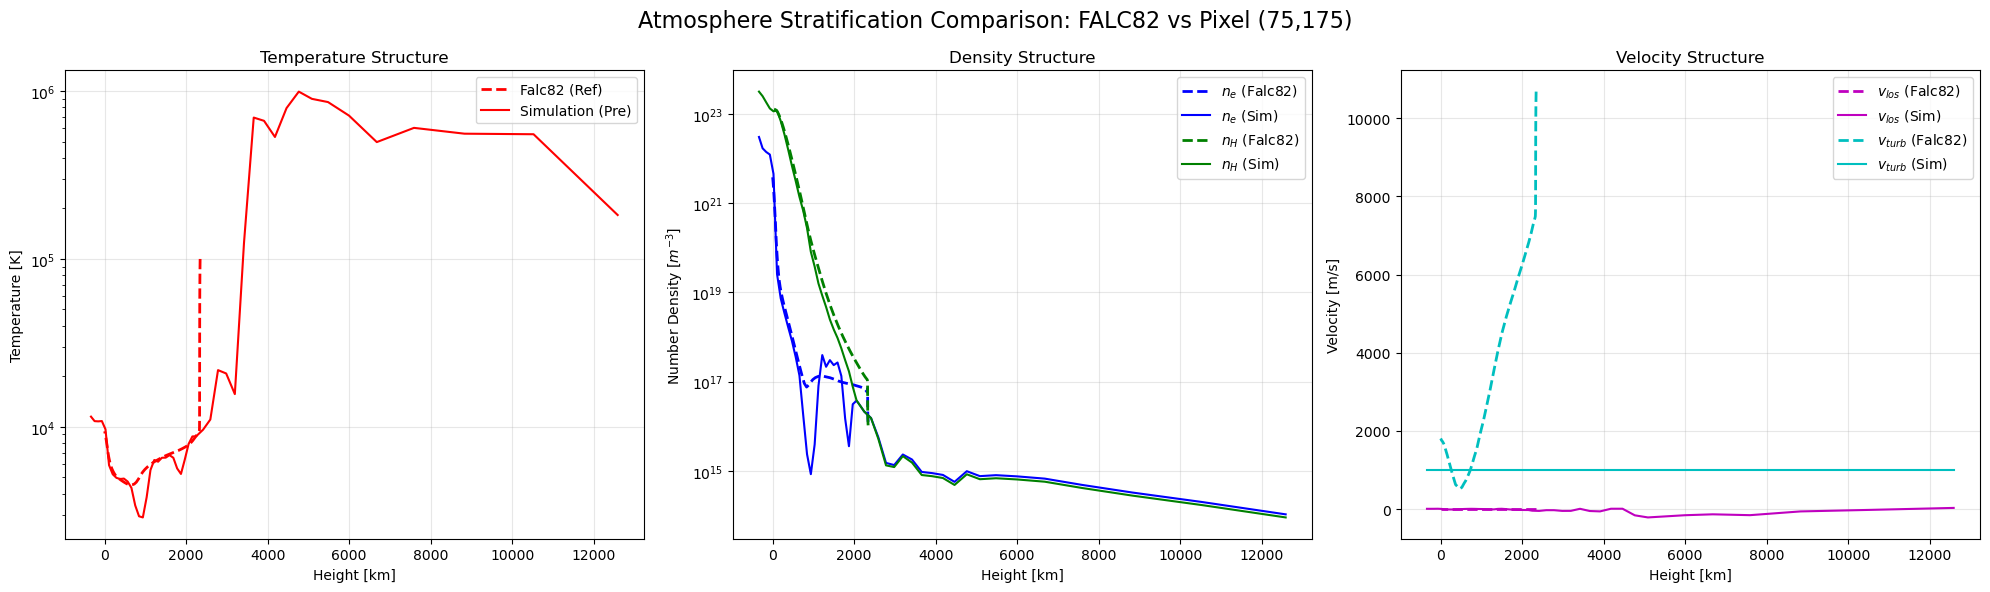

In [15]:
# plot the atmosRef and atmos_pre stratification in all the quantities to compare
# 1. Select a pixel to compare (e.g., the center of the patch)
r_idx = 75
c_idx = 175

print(f"Plotting comparison for pixel coordinates: ({r_idx}, {c_idx})")

# 2. Extract Data for this pixel (using the same logic as your loop)
# Note: applying the [-1:1:-1] slicing as done in the loop
temp_atm_slice = np.ascontiguousarray(temp[-1:1:-1, c_idx, r_idx, 0]) 
vel_atm_slice = np.ascontiguousarray(vel[-1:1:-1, c_idx, r_idx, 2])/1e2 
# n_e_atm_slice = np.ascontiguousarray(n_e[-1:1:-1, c_idx, r_idx, 0])*1e6 
# n_h_atm_slice = np.ascontiguousarray(n_h[-1:1:-1, c_idx, r_idx, 0])*1e6
rho = np.ascontiguousarray(rho[-1:1:-1, c_idx, r_idx, 0])
press = np.ascontiguousarray(press[-1:1:-1, c_idx, r_idx, 0])
height_slice = np.ascontiguousarray(zz_grid_m[-1:1:-1])

# 3. Re-create the Lightweaver atmosphere for this specific pixel
# (We recreate it here to ensure we have the specific object handle for plotting)
atmos_pre_plot = lw.Atmosphere.make_1d(
    scale=lw.ScaleType.Geometric,
    depthScale=height_slice,
    convertScales=False,
    temperature=temp_atm_slice,
    # ne=n_e_atm_slice,
    # nHTot=n_h_atm_slice, 
    Pgas=press,
    vturb=1e3*np.ones_like(temp_atm_slice),
    vlos=vel_atm_slice, 
    verbose=True
)

# ################################################################
atmos_pre_plot.quadrature(5)
aSet = lw.RadiativeSet([H_6_atom(), C_atom(), OI_ord_atom(), Si_atom(), Al_atom(), CaII_atom(),
                        Fe_atom(), He_9_atom(), MgII_atom(), N_atom(), Na_atom(), S_atom()])
aSet.set_active('H', 'Ca')
spect = aSet.compute_wavelength_grid()
eqPops = aSet.compute_eq_pops(atmos_pre_plot)

# Target Populations
# eqPops.atomicPops['Ca'].n = np.ascontiguousarray(np.moveaxis(prediction_atm, 1, 0))
ctx = lw.Context(atmos_pre_plot, spect, eqPops, Nthreads=1, conserveCharge=False)
I_test = ctx.compute_rays(wave, [atmos_pre_plot.muz[-1]], stokes=False)
# ################################################################

# 4. Setup Plotting
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle(f'Atmosphere Stratification Comparison: FALC82 vs Pixel ({r_idx},{c_idx})', fontsize=16)

# Convert heights to km for better readability
h_ref_km = atmosRef.z / 1e3
h_pre_km = atmos_pre_plot.z / 1e3

# --- Plot 1: Temperature ---
axs[0].plot(h_ref_km, atmosRef.temperature, 'r--', linewidth=2, label='Falc82 (Ref)')
axs[0].plot(h_pre_km, atmos_pre_plot.temperature, 'r-', label='Simulation (Pre)')
axs[0].set_xlabel('Height [km]')
axs[0].set_ylabel('Temperature [K]')
axs[0].set_title('Temperature Structure')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# --- Plot 2: Densities (Log Scale) ---
# Electron Density
axs[1].semilogy(h_ref_km, atmosRef.ne, 'b--', linewidth=2, label=r'$n_e$ (Falc82)')
axs[1].semilogy(h_pre_km, atmos_pre_plot.ne, 'b-', label=r'$n_e$ (Sim)')

# Hydrogen Density
axs[1].semilogy(h_ref_km, atmosRef.nHTot, 'g--', linewidth=2, label=r'$n_H$ (Falc82)')
axs[1].semilogy(h_pre_km, atmos_pre_plot.nHTot, 'g-', label=r'$n_H$ (Sim)')

axs[1].set_xlabel('Height [km]')
axs[1].set_ylabel(r'Number Density [$m^{-3}$]')
axs[1].set_title('Density Structure')
# axs[1].set_yscale('log')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

# --- Plot 3: Velocity ---
# LOS Velocity
axs[2].plot(h_ref_km, atmosRef.vlos, 'm--', linewidth=2, label=r'$v_{los}$ (Falc82)')
axs[2].plot(h_pre_km, atmos_pre_plot.vlos, 'm-', label=r'$v_{los}$ (Sim)')

# Microturbulence
axs[2].plot(h_ref_km, atmosRef.vturb, 'c--', linewidth=2, label=r'$v_{turb}$ (Falc82)')
axs[2].plot(h_pre_km, atmos_pre_plot.vturb, 'c-', label=r'$v_{turb}$ (Sim)')

axs[2].set_xlabel('Height [km]')
axs[2].set_ylabel('Velocity [m/s]')
axs[2].set_title('Velocity Structure')
axs[2].legend()
axs[2].grid(True, alpha=0.3)


plt.tight_layout()

save_path_dist = os.path.join(config['training']['savedir'], f'comparison_atmosphere_pixel_{stride}_{dataset_type}_{r_idx}_{c_idx}.png')
plt.savefig(save_path_dist, dpi=300)

plt.show()
# plt.close()

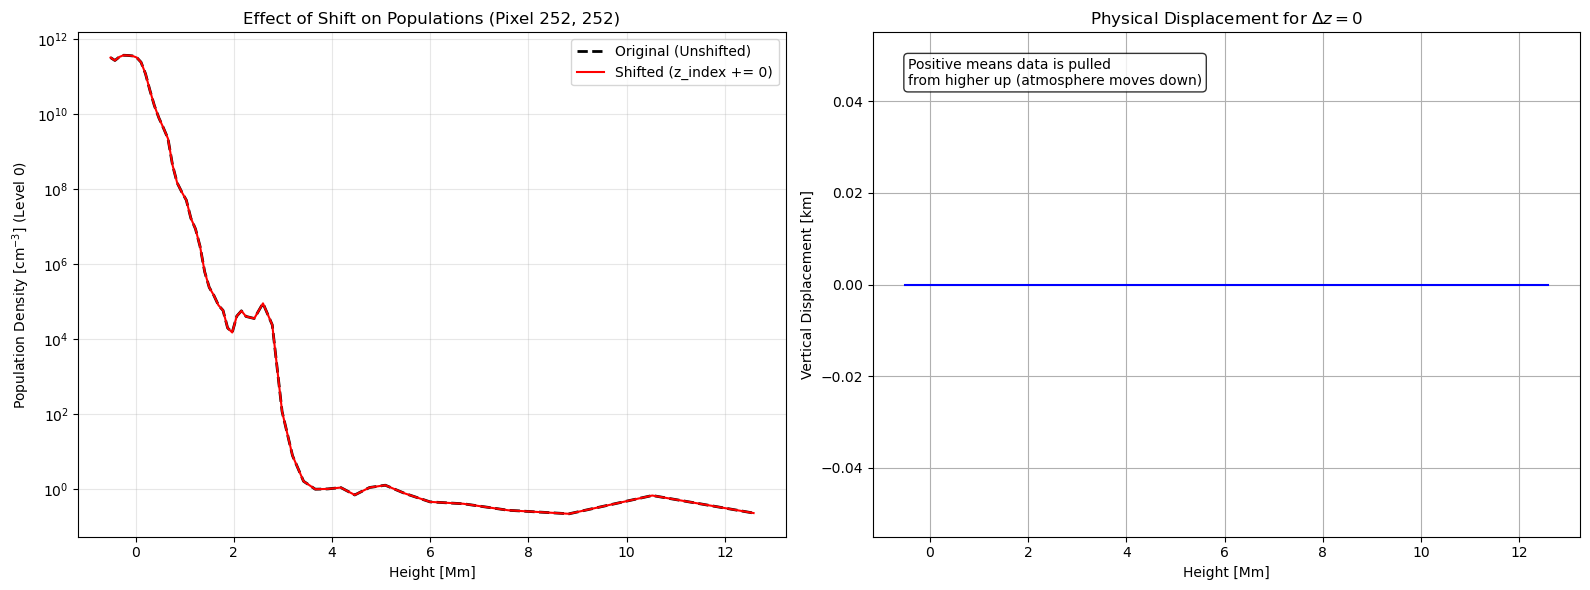

In [16]:
# --- Configuration ---
pixel_x, pixel_y = nx//2, ny//2  # Select center pixel
level_idx = 0             # Select level index to plot (e.g., 0 for ground state)

# --- 1. Extract Data for a Single Pixel ---
# pops_orig is (nz, ny, nx, nlev). We take a slice: (nz, nlev)
# We use .copy() to ensure we have a clean array if it's memory-mapped
pop_col_orig = pops_orig[:, pixel_y, pixel_x, level_idx]

# --- 2. Interpolate 1D Profiles ---
# Create an interpolator for the original z-grid (indices 0 to nz-1)
# We use 'extrapolate' to handle edge cases, though clipping usually prevents this.
f_pop = interp1d(z, pop_col_orig, kind='linear', fill_value="extrapolate")

# Calculate the profiles on the new grid
# Unshifted: Evaluated at new_z
pop_unshifted_1d = f_pop(new_z)

# Shifted: Evaluated at new_z + shift (pulling data from higher indices)
# We clip to ensure we don't go out of the original z bounds
z_shifted_coords = np.clip(new_z + z_shift, 0, nz - 1)
pop_shifted_1d = f_pop(z_shifted_coords)

# --- 3. Calculate Physical Shift (Height) ---
# Determine the effective height shift in km at each point
# geometry_grid is the height in Mm corresponding to integer z indices
f_height = interp1d(z, geometry_grid, kind='linear', fill_value="extrapolate")
h_orig = zz_grid # Height at new_z
h_shifted_source = f_height(z_shifted_coords) # Height at the shifted index
delta_h_km = (h_shifted_source - h_orig) * 1000 # Convert Mm to km

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Populations vs Height
ax1.plot(zz_grid, pop_unshifted_1d, 'k--', label='Original (Unshifted)', linewidth=2)
ax1.plot(zz_grid, pop_shifted_1d, 'r-', label=f'Shifted (z_index += {z_shift})')
ax1.set_yscale('log')
ax1.set_xlabel('Height [Mm]')
ax1.set_ylabel(f'Population Density [cm$^{{-3}}$] (Level {level_idx})')
ax1.set_title(f'Effect of Shift on Populations (Pixel {pixel_x}, {pixel_y})')
ax1.legend()
ax1.grid(True, which="both", ls="-", alpha=0.3)

# Plot 2: Effective Spatial Shift
ax2.plot(zz_grid, delta_h_km, 'b-')
ax2.set_xlabel('Height [Mm]')
ax2.set_ylabel('Vertical Displacement [km]')
ax2.set_title(fr'Physical Displacement for $\Delta z = {z_shift}$')
ax2.grid(True)
ax2.text(0.05, 0.95, 'Positive means data is pulled\nfrom higher up (atmosphere moves down)', 
         transform=ax2.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
save_path_dist = os.path.join(config['training']['savedir'], f'geometry_shift_effect_pixel_{stride}_{dataset_type}_{pixel_x}_{pixel_y}.png')
plt.savefig(save_path_dist, dpi=300)
plt.show()
# plt.close()

In [17]:
print(f"Shape of the synthesized intensities: {Iwave_predicted.shape}, {Iwave_target.shape}, {Iwave_lte.shape}")

Shape of the synthesized intensities: (141, 141, 1001), (141, 141, 1001), (141, 141, 1001)


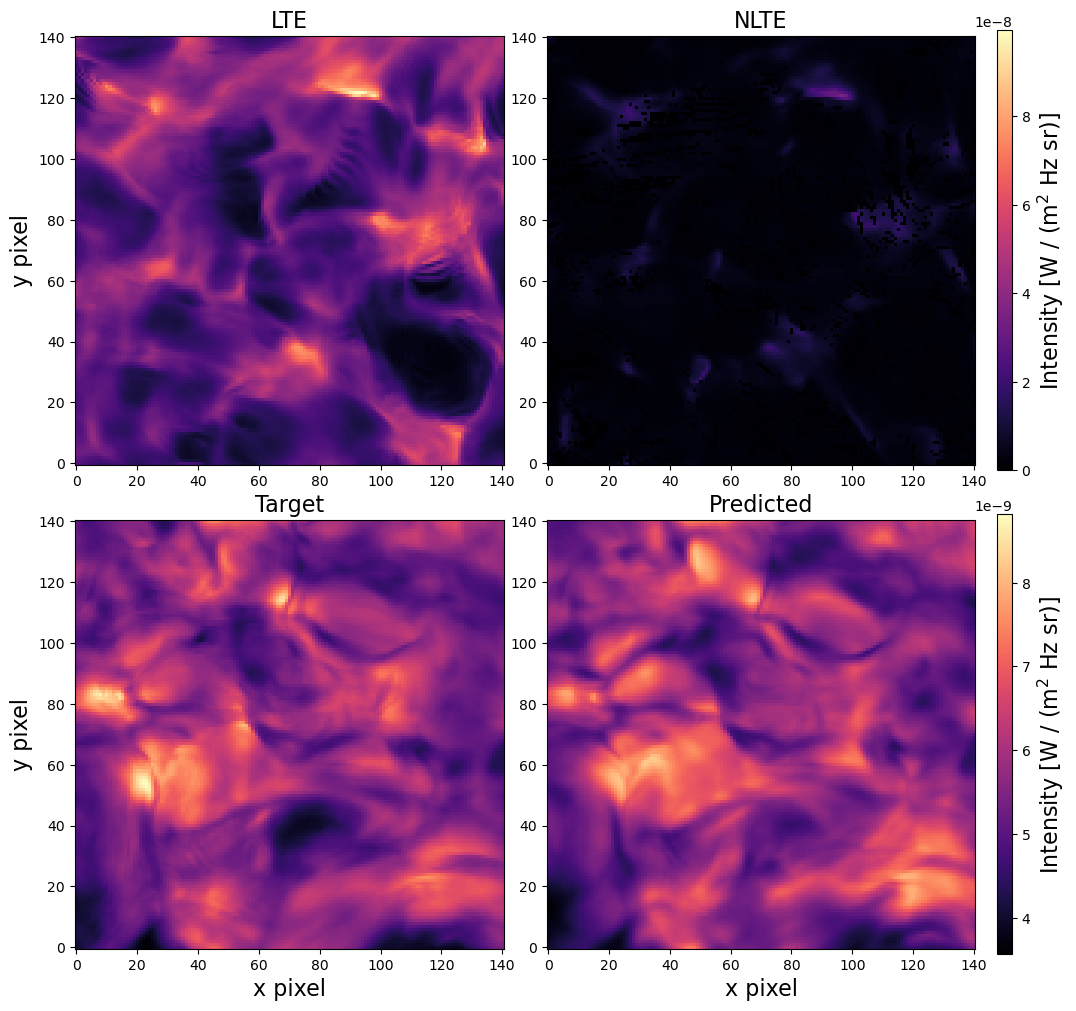

In [18]:
# Calculate Spatially Averaged Spectra for comparison
mean_I_lte = np.mean(Iwave_lte, axis=(0, 1))
mean_I_nlte = np.mean(Iwave_nlte, axis=(0,1), where= Iwave_nlte != 0)
mean_I_orig = np.mean(Iwave_target, axis=(0, 1))
mean_I_pred = np.mean(Iwave_predicted, axis=(0, 1))

# Calculate the index for the line core (approx 854.21 nm for Ca II)
# We find the closest wavelength in the wave array
line_core_idx = np.argmin(mean_I_orig)

# --- Setup the figure ---
# Changed layout to 2 rows, 2 columns. 
# height_ratios gives the maps slightly more vertical space to stay square-ish
fig = plt.figure(figsize=(14, 12), dpi=100)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.1, wspace=0.1)

# Determine color scale limits based on the line core range (Shared for both maps)
vmin = min(np.min(Iwave_lte[:, :, line_core_idx]), np.min(Iwave_lte[:, :, line_core_idx]))*0
vmax = max(np.max(Iwave_lte[:, :, line_core_idx]), np.max(Iwave_lte[:, :, line_core_idx]))

# --- Top Rows: Intensity Maps ---
ax_map_nlte = fig.add_subplot(gs[0, 1])
# Transpose (.T) to align x-axis horizontally
im_nlte= ax_map_nlte.imshow(Iwave_nlte[:, :, line_core_idx].T, 
                                 origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
ax_map_nlte.set_title('NLTE', fontsize=16)
# ax_map_nlte.set_xlabel('x pixel', fontsize=16)
# ax_map_nlte.set_ylabel('y pixel', fontsize=16)

ax_map_lte = fig.add_subplot(gs[0, 0], sharey=ax_map_nlte)
# Transpose (.T) to align x-axis horizontally
im_lte= ax_map_lte.imshow(Iwave_lte[:, :, line_core_idx].T, 
                                 origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
ax_map_lte.set_title('LTE', fontsize=16)
# ax_map_lte.set_xlabel('x pixel', fontsize=16)
ax_map_lte.set_ylabel('y pixel', fontsize=16)

# We attach the colorbar to the list of axes [ax_map_target, ax_map_pred]
cbar = fig.colorbar(im_nlte, ax=[ax_map_lte, ax_map_nlte], 
                    location='right', pad=0.02, aspect=30)
cbar.set_label('Intensity [W / (m$^2$ Hz sr)]', fontsize=16)


# Determine color scale limits based on the line core range (Shared for both maps)
vmin = min(np.min(Iwave_target[:, :, line_core_idx]), np.min(Iwave_predicted[:, :, line_core_idx]))
vmax = max(np.max(Iwave_target[:, :, line_core_idx]), np.max(Iwave_predicted[:, :, line_core_idx]))

# Target Intensity Map
ax_map_target = fig.add_subplot(gs[1, 0], sharex=ax_map_nlte)
# Transpose (.T) to align x-axis horizontally
im_target = ax_map_target.imshow(Iwave_target[:, :, line_core_idx].T, 
                                 origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
ax_map_target.set_title('Target', fontsize=16)
ax_map_target.set_xlabel('x pixel', fontsize=16)
ax_map_target.set_ylabel('y pixel', fontsize=16)

# 2. Predicted Intensity Map
ax_map_pred = fig.add_subplot(gs[1, 1], sharey=ax_map_target, sharex=ax_map_lte)
im_pred = ax_map_pred.imshow(Iwave_predicted[:, :, line_core_idx].T, 
                             origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
ax_map_pred.set_title('Predicted', fontsize=16)
ax_map_pred.set_xlabel('x pixel', fontsize=16)
# ax_map_pred.set_ylabel('y pixel', fontsize=16)

# Shared Colorbar for the top row
# We attach the colorbar to the list of axes [ax_map_target, ax_map_pred]
cbar = fig.colorbar(im_pred, ax=[ax_map_target, ax_map_pred], 
                    location='right', pad=0.02, aspect=30)
cbar.set_label('Intensity [W / (m$^2$ Hz sr)]', fontsize=16)

# plt.tight_layout()
save_path_dist = os.path.join(config['training']['savedir'], f'synthesis_maps_s{stride}_{dataset_type}_{pixel_x}_{pixel_y}.png')
plt.savefig(save_path_dist, dpi=300)
plt.show()

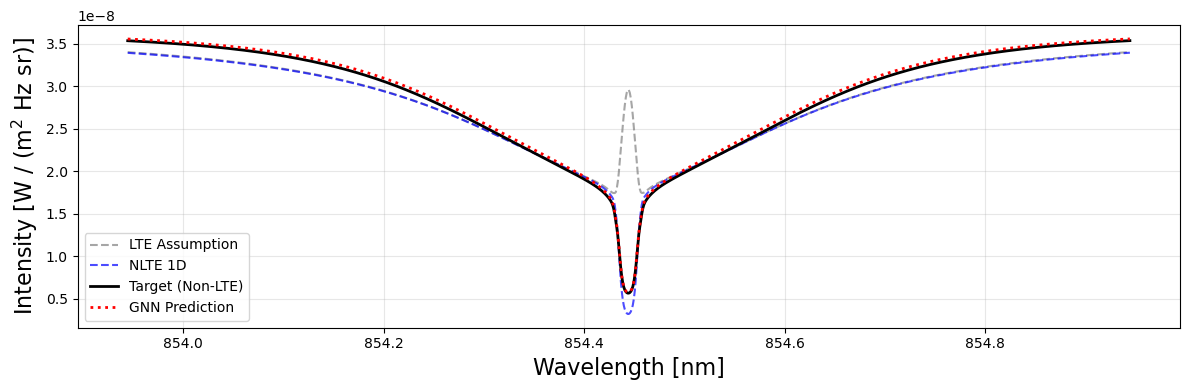

In [19]:
fig = plt.figure(figsize=(12, 4), dpi=100)

# 3. Mean Spectra Comparison (Bottom, Spanning all columns)
plt.plot(wave, mean_I_lte, label='LTE Assumption', color='gray', linestyle='--', alpha=0.7)
plt.plot(wave, mean_I_nlte, label='NLTE 1D', color='blue', linestyle='--', alpha=0.7)
plt.plot(wave, mean_I_orig, label='Target (Non-LTE)', color='black', linewidth=2)
plt.plot(wave, mean_I_pred, label='GNN Prediction', color='red', linestyle=':', linewidth=2)

# plt..set_title('Spatially Averaged Spectra (Ca II 8542)', fontsize=16)
plt.xlabel('Wavelength [nm]', fontsize=16)
plt.ylabel('Intensity [W / (m$^2$ Hz sr)]', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
save_path_dist = os.path.join(config['training']['savedir'], f'synthesis_spectra_s{stride}_{dataset_type}_{pixel_x}_{pixel_y}.png')
plt.savefig(save_path_dist, dpi=300)
plt.show()

IntSlider(value=0, continuous_update=False, description='Wave Index:', layout=Layout(width='80%'), max=1000)

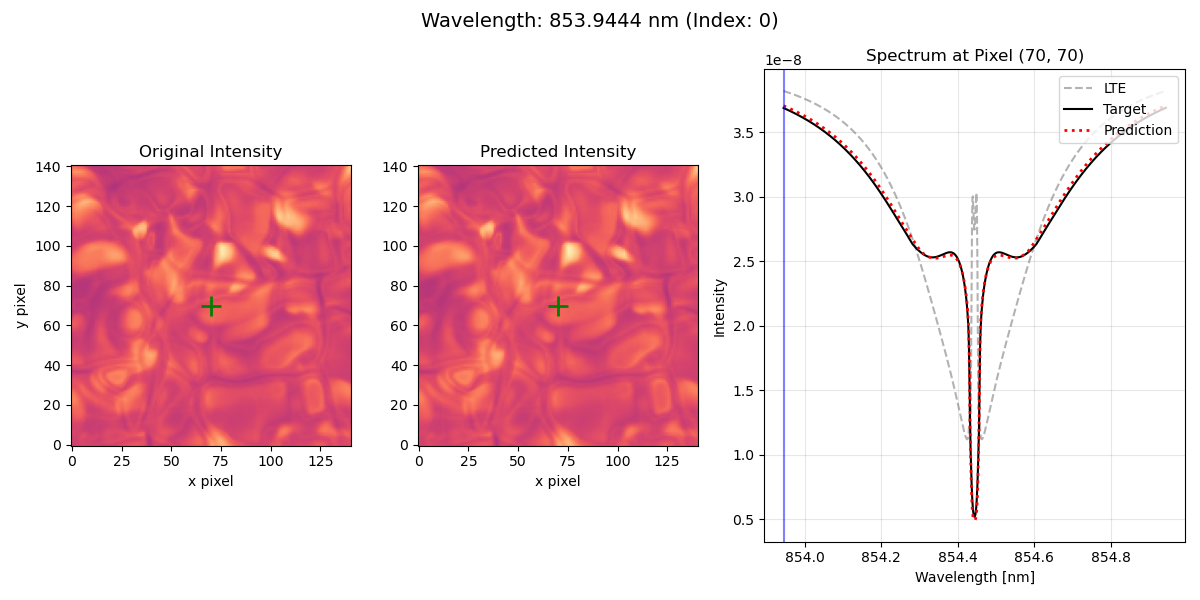

In [20]:
# Try to set up the interactive backend robustly
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

try:
    from IPython import get_ipython
    ipy = get_ipython()
    if ipy:
        # Check if ipympl is installed before trying to switch backend
        import ipympl
        ipy.run_line_magic('matplotlib', 'widget')
except (ImportError, RuntimeError, Exception):
    # Fallback if ipympl is missing
    print("⚠️ Warning: 'ipympl' is not installed or 'widget' backend is unavailable.")
    print("   Run `pip install ipympl` and restart the kernel to enable clicking/sliders.")
    print("   Falling back to inline mode (plots will be static).")
    if ipy:
        ipy.run_line_magic('matplotlib', 'inline')

# ================= Configuration =================
# Global limits for colorbars (fixed across wavelengths to avoid flickering)
vmin = min(np.min(Iwave_target), np.min(Iwave_predicted))
vmax = max(np.max(Iwave_target), np.max(Iwave_predicted))

# Initial pixel selection (center of the image)
sel_x, sel_y = nx_patch // 2, ny_patch // 2

# ================= Setup Figure =================
# We use a constrained layout for better spacing
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.5])

ax_orig = fig.add_subplot(gs[0, 0])
ax_pred = fig.add_subplot(gs[0, 1])
ax_spec = fig.add_subplot(gs[0, 2])

# --- Initial Plots ---
# Note: We use .T (transpose) to match the orientation of the previous plots
# Use 'origin=lower' to match physical coordinates
img_orig = ax_orig.imshow(Iwave_target[:, :, 0].T, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
img_pred = ax_pred.imshow(Iwave_predicted[:, :, 0].T, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)

ax_orig.set_title("Original Intensity")
ax_pred.set_title("Predicted Intensity")
ax_orig.set_xlabel("x pixel")
ax_orig.set_ylabel("y pixel")
ax_pred.set_xlabel("x pixel")

# Add crosshairs to show selected pixel
cross_orig, = ax_orig.plot(sel_x, sel_y, 'g+', markersize=15, markeredgewidth=2)
cross_pred, = ax_pred.plot(sel_x, sel_y, 'g+', markersize=15, markeredgewidth=2)

# --- Spectrum Plot ---
line_lte, = ax_spec.plot(wave, Iwave_lte[sel_x, sel_y, :], 'gray', linestyle='--', alpha=0.6, label='LTE')
line_orig, = ax_spec.plot(wave, Iwave_target[sel_x, sel_y, :], 'k-', linewidth=1.5, label='Target')
line_pred, = ax_spec.plot(wave, Iwave_predicted[sel_x, sel_y, :], 'r:', linewidth=2, label='Prediction')

# Vertical line indicating current wavelength slider position
vline = ax_spec.axvline(wave[0], color='blue', alpha=0.5)

ax_spec.set_title(f"Spectrum at Pixel ({sel_x}, {sel_y})")
ax_spec.set_xlabel("Wavelength [nm]")
ax_spec.set_ylabel("Intensity")
ax_spec.legend(loc='upper right')
ax_spec.grid(True, alpha=0.3)

# ================= Interaction Logic =================

def update_maps(wave_idx):
    """Updates the heatmaps based on the wavelength slider."""
    # Update image data
    img_orig.set_data(Iwave_target[:, :, wave_idx].T)
    img_pred.set_data(Iwave_predicted[:, :, wave_idx].T)
    
    # Update vertical line on spectrum
    vline.set_xdata([wave[wave_idx], wave[wave_idx]])
    
    # Update title to show wavelength
    fig.suptitle(f"Wavelength: {wave[wave_idx]:.4f} nm (Index: {wave_idx})", fontsize=14)
    fig.canvas.draw_idle()

def update_spectrum(x, y):
    """Updates the line plot based on clicked pixel."""
    # Bounds check
    if x < 5 or x >= nx_patch or y < 5 or y >= ny_patch:
        return

    # Update line data
    line_lte.set_ydata(Iwave_lte[x, y, :])
    line_orig.set_ydata(Iwave_target[x, y, :])
    line_pred.set_ydata(Iwave_predicted[x, y, :])
    
    # Update crosshair positions
    cross_orig.set_data([x], [y])
    cross_pred.set_data([x], [y])
    
    # Update title
    ax_spec.set_title(f"Spectrum at Pixel ({int(x)}, {int(y)})")
    
    # Rescale y-axis if necessary (optional, keeps view stable)
    ax_spec.relim()
    ax_spec.autoscale_view()
    
    fig.canvas.draw_idle()

def on_click(event):
    """Handle click events on the images."""
    if event.inaxes in [ax_orig, ax_pred]:
        # Get coordinates
        # Note: Event returns float, need int
        click_x = int(round(event.xdata))
        click_y = int(round(event.ydata))
        
        update_spectrum(click_x, click_y)

# Connect the click event
cid = fig.canvas.mpl_connect('button_press_event', on_click)

# ================= Widget Setup =================

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=nwave - 1,
    step=1,
    description='Wave Index:',
    continuous_update=False, # Update while dragging (set False if laggy)
    layout=widgets.Layout(width='80%')
)

# Link slider to update function
widgets.interactive_output(update_maps, {'wave_idx': slider})

plt.tight_layout()
display(slider)
save_path_dist = os.path.join(config['training']['savedir'], f'comparison_maps_interactive_s{stride}_{dataset_type}.png')
plt.savefig(save_path_dist, dpi=300)
plt.show()
# plt.close()

/tmp/ipykernel_319054/2475426194.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Error distribution plot saved to: checkpoints/multistride_cpudtst_4x4_s4_m8_b8_r6_d025_press/synthesis_error_distribution_s2_test.png


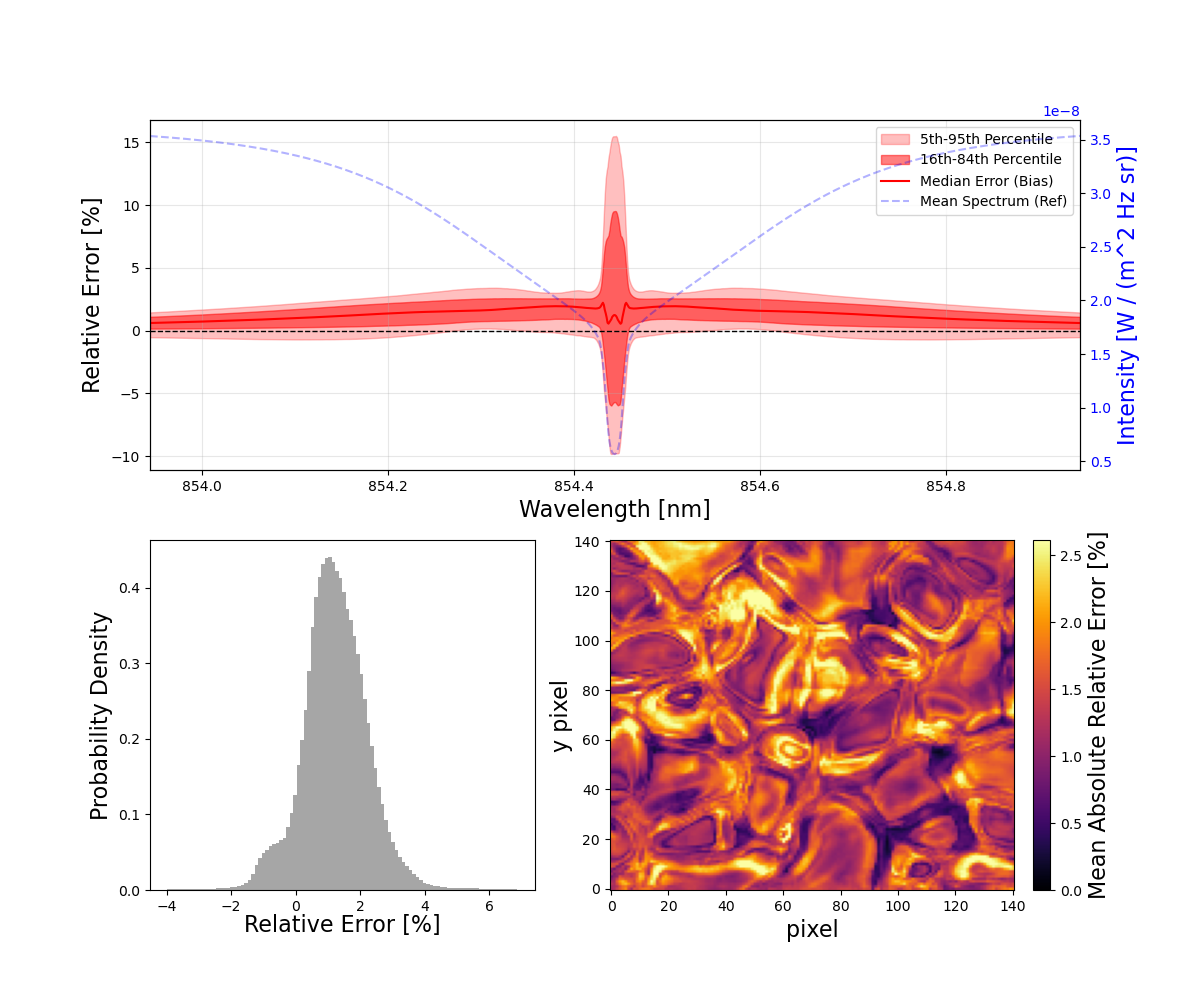

In [21]:
# 1. Calculate Relative Errors (%)
# We add a tiny epsilon to the denominator to ensure numerical stability, 
# though spectral intensity should be > 0.
epsilon = 1e-32
diff = Iwave_predicted - Iwave_target
rel_error = (diff / (Iwave_target + epsilon)) * 100  # Percentage

# 2. Calculate Statistical Aggregates per Wavelength
# This allows us to see if the error is systematic (bias) or random (spread)
# specifically at the line core vs. the wings.
mean_error_spec = np.mean(rel_error, axis=(0, 1))
median_error_spec = np.median(rel_error, axis=(0, 1))
p05_error_spec = np.percentile(rel_error, 5, axis=(0, 1))
p16_error_spec = np.percentile(rel_error, 16, axis=(0, 1)) # -1 sigma approx
p84_error_spec = np.percentile(rel_error, 84, axis=(0, 1)) # +1 sigma approx
p95_error_spec = np.percentile(rel_error, 95, axis=(0, 1))

# 3. Calculate Spatial Error Metrics
# Mean Absolute Percentage Error (MAPE) per pixel across all wavelengths
mape_map = np.mean(np.abs(rel_error), axis=2)

# ==============================================================================
# PLOTTING
# ==============================================================================

fig = plt.figure(figsize=(12, 10), dpi=100)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[0.9, 1.1], wspace=0.175)

# --- Plot 1: Error Distribution vs Wavelength ---
ax1 = fig.add_subplot(gs[0, :])

# Plot the 90% confidence interval (5th to 95th percentile)
ax1.fill_between(wave, p05_error_spec, p95_error_spec, color='red', alpha=0.25, label='5th-95th Percentile')
# Plot the 68% confidence interval (16th to 84th percentile - approx 1 sigma)
ax1.fill_between(wave, p16_error_spec, p84_error_spec, color='red', alpha=0.5, label='16th-84th Percentile')
# Plot the Median Error (Bias)
ax1.plot(wave, median_error_spec, color='red', linewidth=1.5, label='Median Error (Bias)')
# Zero line
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# ax1.set_title(r'Relative Error Distribution vs Wavelength ($Ca II$ 8542)', fontsize=16)
ax1.set_ylabel('Relative Error [%]', fontsize=16)
ax1.set_xlabel('Wavelength [nm]', fontsize=16)
ax1.set_xlim(wave.min(), wave.max())

# Overlay a scaled mean spectrum for context (to see where the core is)
ax1_twin = ax1.twinx()
mean_spectrum = np.mean(Iwave_target, axis=(0,1))
ax1_twin.plot(wave, mean_spectrum, color='blue', alpha=0.3, linestyle='--', label='Mean Spectrum (Ref)')
ax1_twin.set_ylabel(r'Intensity [W / (m^2 Hz sr)]', color='blue', fontsize=16)
ax1_twin.tick_params(axis='y', labelcolor='blue')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Plot 2: Global Histogram of Residuals ---
ax2 = fig.add_subplot(gs[1, 0])

# Flatten the relative error array to get global statistics
flat_rel_error = rel_error.flatten()

# Remove extreme outliers for the histogram visualization (plotting range only)
# We keep the data, just clip the view
viz_range = np.percentile(flat_rel_error, [0.5, 99.5])

bins = 100
n, bins, patches = ax2.hist(flat_rel_error, bins=bins, range=viz_range, 
                            density=True, color='gray', alpha=0.7, label='Data Distribution')

# Fit and plot a Gaussian for comparison
mu, std = np.mean(flat_rel_error), np.std(flat_rel_error)
# p = ((1 / (np.sqrt(2 * np.pi) * std)) *
#      np.exp(-0.5 * (1 / std * (bins - mu))**2))
# ax2.plot(bins, p, 'r--', linewidth=2, label=f'Gaussian Fit\n mu={mu:.2f}%, sigma={std:.2f}%')

# ax2.set_title('Global Histogram of Relative Errors')
ax2.set_xlabel('Relative Error [%]', fontsize=16, labelpad=0)
ax2.set_ylabel('Probability Density', fontsize=16)
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# --- Plot 3: Spatial Map of Mean Absolute Percentage Error (MAPE) ---
ax3 = fig.add_subplot(gs[1, 1])

# Use a colormap that highlights high error (Reds or Magma)
im3 = ax3.imshow(mape_map.T, origin='lower', cmap='inferno', vmin=0, vmax=np.percentile(mape_map, 98), aspect='auto')

# ax3.set_title('Spatial Map of Mean Absolute Percentage Error (MAPE)')
ax3.set_xlabel('pixel', fontsize=16)
ax3.set_ylabel('y pixel', fontsize=16, labelpad=0)

# ax3.yaxis.tick_right()
# ax3.yaxis.set_label_position("right") 

# Add colorbar
cbar = plt.colorbar(im3, ax=ax3, fraction=0.1, pad=0.04)
cbar.set_label('Mean Absolute Relative Error [%]', fontsize=16)

# expand the layout to remove the gaps
plt.tight_layout()

# Save logic
save_path_dist = os.path.join(config['training']['savedir'], f'synthesis_error_distribution_s{stride}_{dataset_type}.png')
plt.savefig(save_path_dist, dpi=300)
print(f"Error distribution plot saved to: {save_path_dist}")

plt.show()
# plt.close()

Error distribution plot saved to: checkpoints/multistride_cpudtst_4x4_s4_m8_b8_r6_d025_press/synthesis_error_distribution_v2_s2_test.png


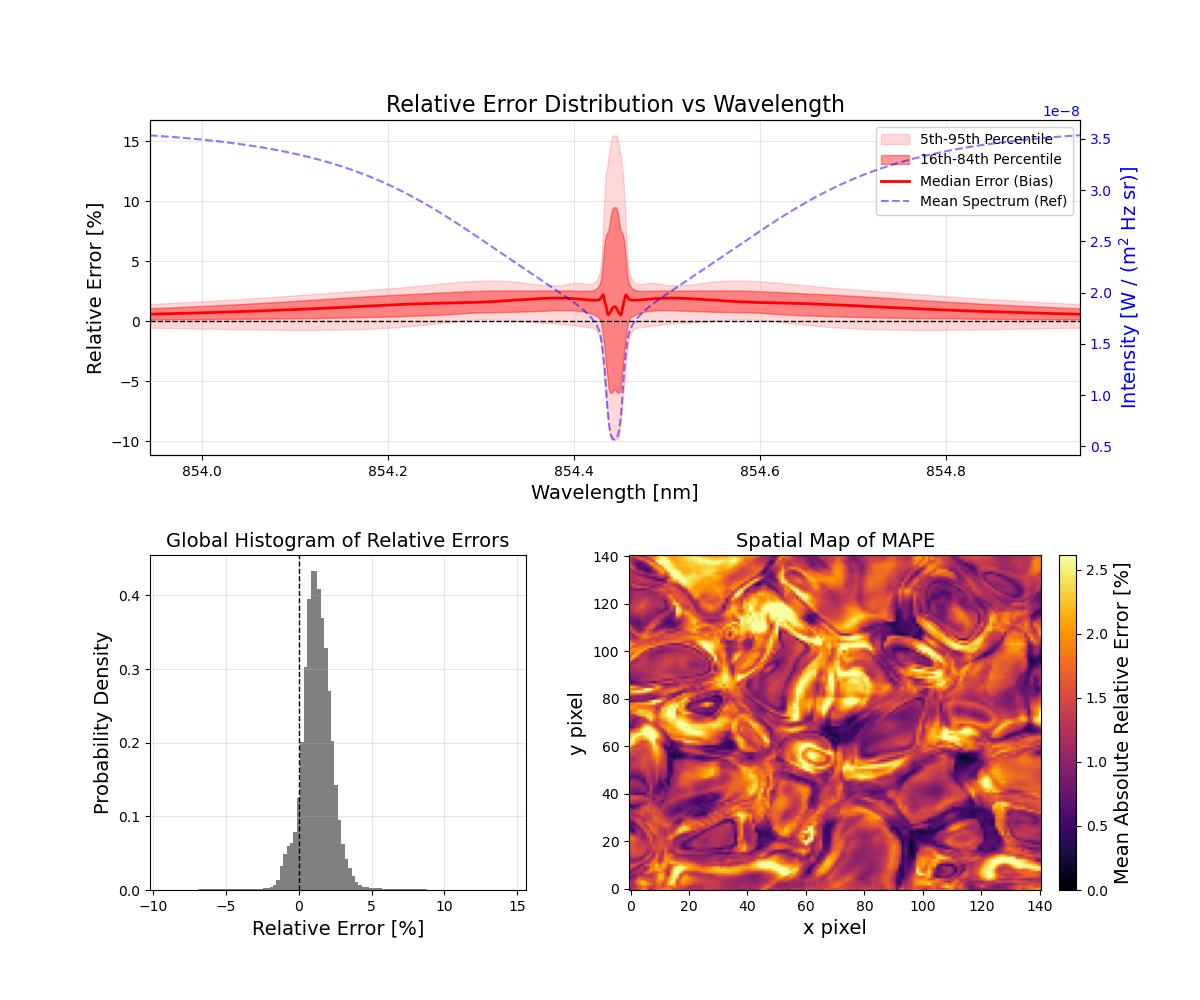

In [22]:
# 1. Calculate Relative Errors (%)
epsilon = 1e-32
diff = Iwave_predicted - Iwave_target
rel_error = (diff / (Iwave_target + epsilon)) * 100  # Percentage

# 2. Calculate Statistical Aggregates per Wavelength
median_error_spec = np.median(rel_error, axis=(0, 1))
p05_error_spec = np.percentile(rel_error, 5, axis=(0, 1))
p16_error_spec = np.percentile(rel_error, 16, axis=(0, 1)) # -1 sigma approx
p84_error_spec = np.percentile(rel_error, 84, axis=(0, 1)) # +1 sigma approx
p95_error_spec = np.percentile(rel_error, 95, axis=(0, 1))

# 3. Calculate Spatial Error Metrics
# Mean Absolute Percentage Error (MAPE) per pixel across all wavelengths
mape_map = np.mean(np.abs(rel_error), axis=2)

# ==============================================================================
# PLOTTING
# ==============================================================================

fig = plt.figure(figsize=(12, 10))
# Adjusted height ratios to give the top spectral plot a bit more room
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1.2], wspace=0.25, hspace=0.3)

# --- Plot 1: Error Distribution vs Wavelength (Top Row) ---
ax1 = fig.add_subplot(gs[0, :])

# Confidence Intervals
ax1.fill_between(wave, p05_error_spec, p95_error_spec, color='red', alpha=0.15, label='5th-95th Percentile')
ax1.fill_between(wave, p16_error_spec, p84_error_spec, color='red', alpha=0.4, label='16th-84th Percentile')
# Median
ax1.plot(wave, median_error_spec, color='red', linewidth=2, label='Median Error (Bias)')
# Zero reference
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

ax1.set_title(r'Relative Error Distribution vs Wavelength', fontsize=16)
ax1.set_ylabel('Relative Error [%]', fontsize=14)
ax1.set_xlabel('Wavelength [nm]', fontsize=14)
ax1.set_xlim(wave.min(), wave.max())
ax1.grid(True, alpha=0.3)

# Overlay Mean Spectrum for context
ax1_twin = ax1.twinx()
mean_spectrum = np.mean(Iwave_target, axis=(0,1))
ax1_twin.plot(wave, mean_spectrum, color='blue', alpha=0.5, linestyle='--', linewidth=1.5, label='Mean Spectrum (Ref)')
ax1_twin.set_ylabel(r'Intensity [W / (m$^2$ Hz sr)]', color='blue', fontsize=14)
ax1_twin.tick_params(axis='y', labelcolor='blue')

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right', framealpha=0.9)

# --- Plot 2: Global Histogram of Residuals (Bottom Left) ---
ax2 = fig.add_subplot(gs[1, 0])

flat_rel_error = rel_error.flatten()
# Range for visualization (clip extreme outliers just for the plot view)
viz_range = np.percentile(flat_rel_error, [0.1, 99.9])

# Histogram
bins = 100
ax2.hist(flat_rel_error, bins=bins, range=viz_range, density=True, color='gray', alpha=1.0)

ax2.set_title('Global Histogram of Relative Errors', fontsize=14)
ax2.set_xlabel('Relative Error [%]', fontsize=14)
ax2.set_ylabel('Probability Density', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axvline(0, color='black', linestyle='--', linewidth=1) # Zero reference

# --- Plot 3: Spatial Map of MAPE (Bottom Right) ---
ax3 = fig.add_subplot(gs[1, 1])

# Plotting the transpose to match previous map orientation
im3 = ax3.imshow(mape_map.T, origin='lower', cmap='inferno', 
                 vmin=0, vmax=np.percentile(mape_map, 98), aspect='auto')

ax3.set_title('Spatial Map of MAPE', fontsize=14)
ax3.set_xlabel('x pixel', fontsize=14)
ax3.set_ylabel('y pixel', fontsize=14)

# Colorbar attached specifically to this axes
cbar = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label('Mean Absolute Relative Error [%]', fontsize=14)

# plt.tight_layout() # tight_layout can sometimes conflict with complex gridspecs, simple show works best with manual gs spacing
save_path_dist = os.path.join(config['training']['savedir'], f'synthesis_error_distribution_v2_s{stride}_{dataset_type}.png')
plt.savefig(save_path_dist, dpi=300)
print(f"Error distribution plot saved to: {save_path_dist}")

plt.show()

In [23]:
# Print summary statistics
print("=== Error Statistics ===")
print(f"Global Mean Relative Error (Bias): {mu:.4f} %")
print(f"Global Std Dev of Relative Error:  {std:.4f} %")
print(f"Max Pixel MAPE: {np.max(mape_map):.4f} %")
print(f"Mean Pixel MAPE: {np.mean(mape_map):.4f} %")

=== Error Statistics ===
Global Mean Relative Error (Bias): 1.2490 %
Global Std Dev of Relative Error:  1.4392 %
Max Pixel MAPE: 3.8077 %
Mean Pixel MAPE: 1.4428 %
